# PTB-XL Exploratory Data Analysis

## Synthetic ECG Signal Generation for Cardiac Data Augmentation

This notebook explores the PTB-XL metadata to understand the diagnostic labels, class distribution and data quality before building a Conditional Variational Autoencoder (CVAE). The findings in each section are used to guide the preprocessing and modelling decisions.


## 1. Imports

In [33]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from collections import Counter
from sklearn.preprocessing import MultiLabelBinarizer

plt.style.use("default")
pd.set_option("display.max_columns", None)

## 2. Load PTB-XL Metadata

In [34]:
DATASET_PATH = Path("./physionet.org/files/ptb-xl/1.0.3")
metadata = pd.read_csv(DATASET_PATH / "ptbxl_database.csv")
scp = pd.read_csv(DATASET_PATH / "scp_statements.csv")

print(metadata.shape)
metadata.head()

(21799, 28)


,ecg_id,patient_id,age,sex,height,weight,nurse,site,device,recording_date,report,scp_codes,heart_axis,infarction_stadium1,infarction_stadium2,validated_by,second_opinion,initial_autogenerated_report,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
0,1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,sinusrhythmus periphere niederspannung,"{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}",NaN,NaN,NaN,NaN,False,False,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
1,2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,sinusbradykardie sonst normales ekg,"{'NORM': 80.0, 'SBRAD': 0.0}",NaN,NaN,NaN,NaN,False,False,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
2,3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,sinusrhythmus normales ekg,"{'NORM': 100.0, 'SR': 0.0}",NaN,NaN,NaN,NaN,False,False,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr
3,4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,sinusrhythmus normales ekg,"{'NORM': 100.0, 'SR': 0.0}",NaN,NaN,NaN,NaN,False,False,True,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr
4,5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,sinusrhythmus normales ekg,"{'NORM': 100.0, 'SR': 0.0}",NaN,NaN,NaN,NaN,False,False,True,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr


## 3. Inspect Metadata

This section briefly inspects the metadata structure and the SCP annotation table before creating diagnostic labels.


In [35]:
len(metadata)

21799

In [36]:
metadata.info()

<class 'pandas.DataFrame'>
RangeIndex: 21799 entries, 0 to 21798
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ecg_id                        21799 non-null  int64  
 1   patient_id                    21799 non-null  float64
 2   age                           21799 non-null  float64
 3   sex                           21799 non-null  int64  
 4   height                        6974 non-null   float64
 5   weight                        9421 non-null   float64
 6   nurse                         20326 non-null  float64
 7   site                          21782 non-null  float64
 8   device                        21799 non-null  str    
 9   recording_date                21799 non-null  str    
 10  report                        21799 non-null  str    
 11  scp_codes                     21799 non-null  str    
 12  heart_axis                    13331 non-null  str    
 13  infarction_s

In [37]:
scp.head()

,Unnamed: 0,description,diagnostic,form,rhythm,diagnostic_class,diagnostic_subclass,Statement Category,SCP-ECG Statement Description,AHA code,aECG REFID,CDISC Code,DICOM Code
0,NDT,non-diagnostic T abnormalities,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,non-diagnostic T abnormalities,NaN,NaN,NaN,NaN
1,NST_,non-specific ST changes,1.0,1.0,NaN,STTC,NST_,Basic roots for coding ST-T changes and abnorm...,non-specific ST changes,145.0,MDC_ECG_RHY_STHILOST,NaN,NaN
2,DIG,digitalis-effect,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,suggests digitalis-effect,205.0,NaN,NaN,NaN
3,LNGQT,long QT-interval,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,long QT-interval,148.0,NaN,NaN,NaN
4,NORM,normal ECG,1.0,NaN,NaN,NORM,NORM,Normal/abnormal,normal ECG,1.0,NaN,NaN,F-000B7


## 4. Explore SCP Codes
The diagnosis of each ECG is stored as SCP statements. We first inspect their format before mapping them into diagnostic superclasses.

In [38]:
metadata["scp_codes"].head(50)

0              {'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}
1                          {'NORM': 80.0, 'SBRAD': 0.0}
2                            {'NORM': 100.0, 'SR': 0.0}
3                            {'NORM': 100.0, 'SR': 0.0}
4                            {'NORM': 100.0, 'SR': 0.0}
5                            {'NORM': 100.0, 'SR': 0.0}
6                            {'NORM': 100.0, 'SR': 0.0}
7                {'IMI': 35.0, 'ABQRS': 0.0, 'SR': 0.0}
8                            {'NORM': 100.0, 'SR': 0.0}
9                            {'NORM': 100.0, 'SR': 0.0}
10                         {'NORM': 80.0, 'SARRH': 0.0}
11                         {'NORM': 80.0, 'SBRAD': 0.0}
12                           {'NORM': 100.0, 'SR': 0.0}
13                           {'NORM': 100.0, 'SR': 0.0}
14                        {'NORM': 100.0, 'SARRH': 0.0}
15                           {'NORM': 100.0, 'SR': 0.0}
16           {'AFLT': 100.0, 'ABQRS': 0.0, 'AFIB': 0.0}
17                                      {'AFLT':

In [39]:
# Convert strings into dictionaries
metadata["scp_codes"] = metadata["scp_codes"].apply(ast.literal_eval)

all_codes = Counter()

for row in metadata["scp_codes"]:
    all_codes.update(row.keys())

print(f"Unique SCP codes: {len(all_codes)}")

Unique SCP codes: 71


In [40]:
scp[["diagnostic", "form", "rhythm"]].notna().sum()

diagnostic    44
form          19
rhythm        12
dtype: int64

## 5. Inspect the Diagnostic Classe and Superclasses

Only diagnostic SCP statements are used. Rhythm and form statements are ignored.


In [41]:
diagnostic = (
    scp[scp["diagnostic"] == 1]
    .rename(columns={"Unnamed: 0": "scp_code"})
)

diagnostic_mapping = diagnostic.set_index("scp_code")[
    ["diagnostic_class", "description"]
]

diagnostic_mapping.index.name = "scp_code"
diagnostic_mapping.groupby("diagnostic_class").size()

diagnostic_class
CD      11
HYP      5
MI      14
NORM     1
STTC    13
dtype: int64

In [42]:
diagnostic_mapping.sort_values("diagnostic_class")

,diagnostic_class,description
scp_code,,
2AVB,CD,second degree AV block
WPW,CD,Wolf-Parkinson-White syndrome
CLBBB,CD,complete left bundle branch block
CRBBB,CD,complete right bundle branch block
ILBBB,CD,incomplete left bundle branch block
IVCD,CD,non-specific intraventricular conduction distu...
1AVB,CD,first degree AV block
LAFB,CD,left anterior fascicular block
IRBBB,CD,incomplete right bundle branch block


In [43]:
print("Unique diagnostic superclasses:")
print(sorted(diagnostic_mapping["diagnostic_class"].unique()))

Unique diagnostic superclasses:
['CD', 'HYP', 'MI', 'NORM', 'STTC']


## 6. Map ECGs to Diagnostic Superclasses
Each ECG is mapped to one or more of the five PTB-XL diagnostic superclasses.

In [44]:
# Build a mapping dictionary
diag_map = diagnostic_mapping["diagnostic_class"].to_dict()

# Map every ECG into its super class diagnostic
def map_superclasses(labels):
    return sorted({
        diag_map[code]
        for code in labels
        if code in diag_map
    })

metadata["superclasses"] = metadata["scp_codes"].apply(map_superclasses)

metadata[["scp_codes","superclasses"]].head(10)

,scp_codes,superclasses
0,"{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}",[NORM]
1,"{'NORM': 80.0, 'SBRAD': 0.0}",[NORM]
2,"{'NORM': 100.0, 'SR': 0.0}",[NORM]
3,"{'NORM': 100.0, 'SR': 0.0}",[NORM]
4,"{'NORM': 100.0, 'SR': 0.0}",[NORM]
5,"{'NORM': 100.0, 'SR': 0.0}",[NORM]
6,"{'NORM': 100.0, 'SR': 0.0}",[NORM]
7,"{'IMI': 35.0, 'ABQRS': 0.0, 'SR': 0.0}",[MI]
8,"{'NORM': 100.0, 'SR': 0.0}",[NORM]
9,"{'NORM': 100.0, 'SR': 0.0}",[NORM]


In [45]:
# Lets check how many data entries have no diagnostic label
empty_superclasses = metadata["superclasses"].str.len() == 0
print(f"ECGs without diagnostic superclass: {empty_superclasses.sum()}")
print(f"Percentage: {100*empty_superclasses.mean():.2f}%")

ECGs without diagnostic superclass: 411
Percentage: 1.89%


In [46]:
# Delete ECGs that don't have a diagnostic label 
# Less than 2% is a resonable deduction in dataset
metadata = metadata[
    metadata["superclasses"].str.len() > 0
].reset_index(drop=True)

print(len(metadata))
empty_superclasses = metadata["superclasses"].str.len() == 0
print(f"ECGs without diagnostic superclass: {empty_superclasses.sum()}")

21388
ECGs without diagnostic superclass: 0


## 7. Explore Diagnostic Class Distribution
Study the distribution of diagnostic labels and combinations to determine whether a single-label or multi-label baseline is more suitable.

superclasses
NORM    9514
MI      5469
STTC    5235
CD      4898
HYP     2649
Name: count, dtype: int64

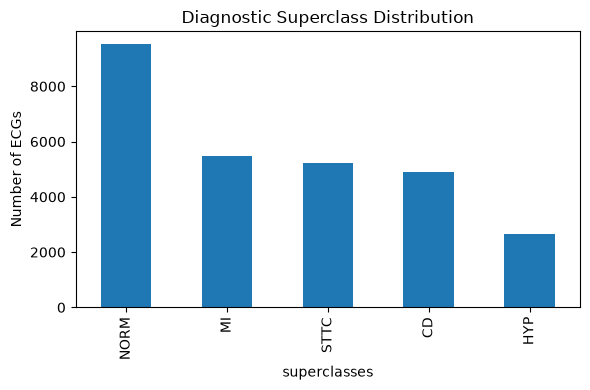

In [47]:
superclass_counts = (
    metadata["superclasses"]
    .explode()
    .value_counts()
    .sort_values(ascending=False)
)

display(superclass_counts)

plt.figure(figsize=(6,4))
superclass_counts.plot(kind="bar")
plt.title("Diagnostic Superclass Distribution")
plt.ylabel("Number of ECGs")
plt.tight_layout()
plt.show()

superclasses
1    16244
2     4068
3      919
4      157
Name: count, dtype: int64

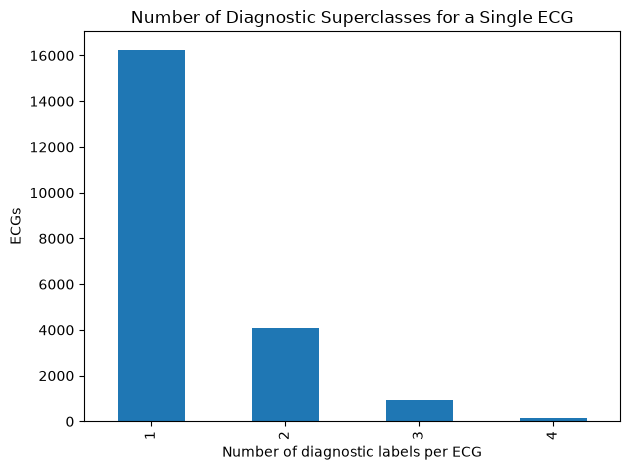

In [48]:
label_count = metadata["superclasses"].str.len().value_counts().sort_index()

display(label_count)

label_count.plot(kind="bar")
plt.title("Number of Diagnostic Superclasses for a Single ECG")
plt.xlabel("Number of diagnostic labels per ECG")
plt.ylabel("ECGs")
plt.tight_layout()
plt.show()

**Finding**

Most ECGs contain a single diagnostic superclass. This motivates using a single-label baseline model before extending to multi-label generation.


## 8. Explore Diagnostic Label Combinations

In [49]:
combination_counts = (
    metadata["superclasses"]
    .apply(tuple)
    .value_counts()
    .rename_axis("Combination")
    .reset_index(name="Count")
)

display(combination_counts.head(30))

,Combination,Count
0,"(NORM,)",9069
1,"(MI,)",2532
2,"(STTC,)",2400
3,"(CD,)",1708
4,"(CD, MI)",1297
5,"(HYP, STTC)",781
6,"(MI, STTC)",599
7,"(HYP,)",535
8,"(CD, STTC)",471
9,"(CD, NORM)",407


In [50]:
rare_threshold = 200

rare_combinations = combination_counts[
    combination_counts["Count"] < rare_threshold
]

display(rare_combinations)

,Combination,Count
14,"(HYP, MI)",183
15,"(CD, HYP, MI, STTC)",156
16,"(CD, HYP, MI)",117
17,"(NORM, STTC)",28
18,"(CD, NORM, STTC)",5
19,"(CD, HYP, NORM)",2
20,"(HYP, NORM)",2
21,"(CD, HYP, MI, NORM)",1


In [51]:
print(f"Number of rare combinations: {len(rare_combinations)}")

print(
    f"Total ECGs in rare combinations: "
    f"{rare_combinations['Count'].sum()}"
)

Number of rare combinations: 8
Total ECGs in rare combinations: 494


In [52]:
# Remove ECGs belonging to rare combinations
rare_set = set(rare_combinations["Combination"])

metadata = (
    metadata[
        ~metadata["superclasses"].apply(tuple).isin(rare_set)
    ]

    .reset_index(drop=True)
)

remaining_combinations = (
    metadata["superclasses"]
    .apply(tuple)
    .value_counts()
)

print("Rare combinations remaining:",remaining_combinations.index.isin(rare_set).sum())
print(f"Remaining ECGs: {len(metadata)}")

Rare combinations remaining: 0
Remaining ECGs: 20894


## 9. Label Relationships
Analyse co-occurrence between diagnostic superclasses and distinguish pure and multi-label recordings.

In [53]:
mlb = MultiLabelBinarizer()

label_matrix = pd.DataFrame(
    mlb.fit_transform(metadata["superclasses"]),
    columns=mlb.classes_,
    index=metadata.index
)

label_matrix.head(10)

,CD,HYP,MI,NORM,STTC
0,0,0,0,1,0
1,0,0,0,1,0
2,0,0,0,1,0
3,0,0,0,1,0
4,0,0,0,1,0
5,0,0,0,1,0
6,0,0,0,1,0
7,0,0,1,0,0
8,0,0,0,1,0
9,0,0,0,1,0


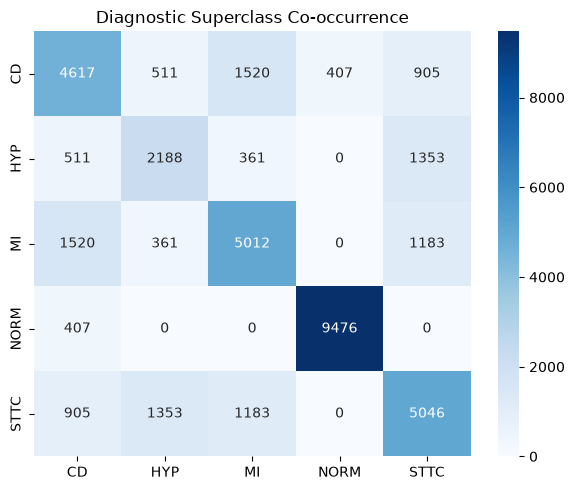

In [54]:
co_occurrence = label_matrix.T @ label_matrix

plt.figure(figsize=(6,5))
sns.heatmap(co_occurrence, annot=True, fmt="d", cmap="Blues")
plt.title("Diagnostic Superclass Co-occurrence")
plt.tight_layout()
plt.show()

,Total,Pure,2 Labels,3 Labels,4 Labels,Total Multi-label,Total Multi-label (%)
NORM,9476,9069,407,0,0,407,4.3
STTC,5046,2400,1851,795,0,2646,52.4
MI,5012,2532,1896,584,0,2480,49.5
CD,4617,1708,2475,434,0,2909,63.0
HYP,2188,535,1081,572,0,1653,75.5


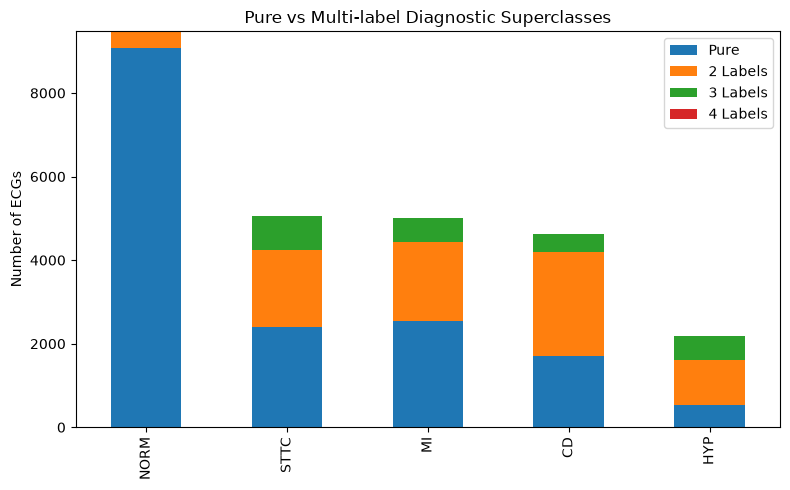

In [55]:
summary = pd.DataFrame(index=mlb.classes_)
summary["Total"] = label_matrix.sum()

summary["Pure"] = [
    ((label_matrix[c]==1)&(label_matrix.sum(axis=1)==1)).sum()
    for c in mlb.classes_
]

summary["2 Labels"] = [
    ((label_matrix[c]==1)&(label_matrix.sum(axis=1)==2)).sum()
    for c in mlb.classes_
]

summary["3 Labels"] = [
    ((label_matrix[c]==1)&(label_matrix.sum(axis=1)==3)).sum()
    for c in mlb.classes_
]

summary["4 Labels"] = summary["Total"]-summary["Pure"]-summary["2 Labels"]-summary["3 Labels"]
summary["Total Multi-label"] = summary["2 Labels"]+summary["3 Labels"]+summary["4 Labels"]
summary["Total Multi-label (%)"]=(100*summary["Total Multi-label"]/summary["Total"]).round(1)
summary = summary.sort_values("Total", ascending=False)

display(summary)

summary[["Pure","2 Labels", "3 Labels", "4 Labels"]].plot(kind="bar",stacked=True, figsize=(8,5))
plt.ylabel("Number of ECGs")
plt.title("Pure vs Multi-label Diagnostic Superclasses")
plt.tight_layout()
plt.show()

In [56]:
# Keep only ECGs with one or two diagnostic labels
before = len(metadata)

metadata = (
    metadata[
        metadata["superclasses"].str.len() <= 2
    ]
    .reset_index(drop=True)
)

removed = before - len(metadata)

print(f"Removed {removed} ECGs with more than 2 diagnostic labels ({removed / before * 100:.2f}%)")
print(f"Remaining ECGs: {len(metadata)}")
metadata["superclasses"].str.len().value_counts().sort_index()

Removed 795 ECGs with more than 2 diagnostic labels (3.80%)
Remaining ECGs: 20099


superclasses
1    16244
2     3855
Name: count, dtype: int64

## 10. Inspect Lead II Noise

In [57]:
noise_columns=[
    "baseline_drift",
    "static_noise",
    "burst_noise",
    "electrodes_problems"
]

def has_leadII_noise(value):
    if pd.isna(value):
        return False
    leads=[x.strip() for x in str(value).split(",") if x.strip()]
    return "II" in leads

noise_summary={}

for c in noise_columns:
    noise_summary[c]=metadata[c].apply(has_leadII_noise).sum()

any_noise=metadata[noise_columns].apply(
    lambda r:any(has_leadII_noise(v) for v in r),axis=1
)

noise_summary["Any Lead II Noise"]=any_noise.sum()

noise_summary=pd.DataFrame({
    "Count":pd.Series(noise_summary)
})
noise_summary["Percentage (%)"]=(100*noise_summary["Count"]/len(metadata)).round(2)

display(noise_summary)

,Count,Percentage (%)
baseline_drift,85,0.42
static_noise,54,0.27
burst_noise,22,0.11
electrodes_problems,0,0.00
Any Lead II Noise,161,0.80


In [58]:
noisy_ecgs=metadata[any_noise].copy()

noisy_label_counts=(
    noisy_ecgs["superclasses"]
    .apply(tuple)
    .value_counts()
    .rename_axis("Combination")
    .reset_index(name="Count")
)

display(noisy_label_counts)

,Combination,Count
0,"(NORM,)",81
1,"(MI,)",19
2,"(STTC,)",16
3,"(CD,)",15
4,"(CD, MI)",13
5,"(MI, STTC)",5
6,"(HYP, STTC)",5
7,"(CD, STTC)",4
8,"(HYP,)",2
9,"(CD, NORM)",1


In [59]:
# Remove noisy ECGs
before = len(metadata)

any_noise=metadata[noise_columns].apply(
    lambda r:any(has_leadII_noise(v) for v in r),axis=1
)

metadata = (
    metadata[~any_noise]
    .reset_index(drop=True)
)

remaining_noise = metadata[noise_columns].apply(
    lambda row: any(has_leadII_noise(value) for value in row),
    axis=1
).sum()

removed = before - len(metadata)
print(f"Removed {removed} noisy ECGs ({removed / before * 100:.2f}%)")
print(f"Lead II noisy ECGs remaining: {remaining_noise}")
print(f"Remaining ECGs: {len(metadata)}")

Removed 161 noisy ECGs (0.80%)
Lead II noisy ECGs remaining: 0
Remaining ECGs: 19938


**Finding**

Very few ECGs contain Lead II noise. These recordings will be removed during preprocessing to improve signal quality without significantly reducing the dataset.


## 11. Reducing Class Imbalance
To reduce class imbalance, the NORM class is randomly undersampled to approximately 4,000 recordings while all other diagnostic classes are retained unchanged.

In [61]:
# Randomly reduce the NORM class to approximately 4000 recordings
TARGET_NORM = 4050
RANDOM_STATE = 42

norm_mask = metadata["superclasses"].apply(lambda x: tuple(x) == ("NORM",))
norm_ecgs = metadata[norm_mask]
other_ecgs = metadata[~norm_mask]

print(f"NORM before: {len(norm_ecgs)}")

norm_sampled = norm_ecgs.sample(
    n=TARGET_NORM,
    random_state=RANDOM_STATE
)

metadata = (
    pd.concat([norm_sampled, other_ecgs], ignore_index=True)
    .sample(frac=1, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

print(f"NORM after: {(metadata['superclasses'].apply(lambda x: tuple(x)==('NORM',))).sum()}")
print(f"Total ECGs: {len(metadata)}")

NORM before: 8988
NORM after: 4050
Total ECGs: 15000


## 12. Verify Official Stratified Folds
Verify that the official PTB-XL folds preserve a similar class distribution.

In [62]:
fold_df = (
    metadata[["strat_fold","superclasses"]]
    .explode("superclasses")
    .reset_index(drop=True)
)

fold_distribution = (
    fold_df
    .groupby(["strat_fold","superclasses"])
    .size()
    .unstack(fill_value=0)
)

display(fold_distribution)

superclasses,CD,HYP,MI,NORM,STTC
strat_fold,,,,,
1,401,147,446,433,428
2,409,163,432,447,423
3,418,172,433,467,423
4,427,174,453,458,433
5,422,152,439,459,429
6,412,175,456,414,429
7,402,146,431,460,410
8,423,166,438,439,417
9,416,159,419,443,418


## 13. Final Baseline Dataset

In [63]:
combination_counts = (
    metadata["superclasses"]
    .apply(tuple)
    .value_counts()
    .rename_axis("Combination")
    .reset_index(name="Count")
)

print(f"Total ECGs: {len(metadata)}")
print(f"Number of classes: {metadata['superclasses'].apply(tuple).nunique()}")

display(combination_counts)

Total ECGs: 15000
Number of classes: 11


,Combination,Count
0,"(NORM,)",4050
1,"(MI,)",2513
2,"(STTC,)",2384
3,"(CD,)",1693
4,"(CD, MI)",1284
5,"(HYP, STTC)",776
6,"(MI, STTC)",594
7,"(HYP,)",533
8,"(CD, STTC)",467
9,"(CD, NORM)",406


# 14. Baseline Design Decisions

Based on the analysis:

- Remove ECGs without diagnostic labels.
- Remove ECGs with Lead II baseline drift, static noise or burst noise.
- Treat common two-label diagnostic combinations as independent classes.
- Remove ECGs with more than two diagnostic labels.
- Remove diagnostic classes with fewer than 300 recordings.
- Randomly reduce the NORM class to approximately **4000** recordings.
- Use balanced mini-batch sampling during training.
- Use Lead II as the baseline input signal.
